In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.stats as stats

### A. Null and Alternative Hypothesis

In [7]:
# Parameters
threshold = 0.9  # 1 - significance_level
mean_null, mean_alt = 0, 3
std = 1

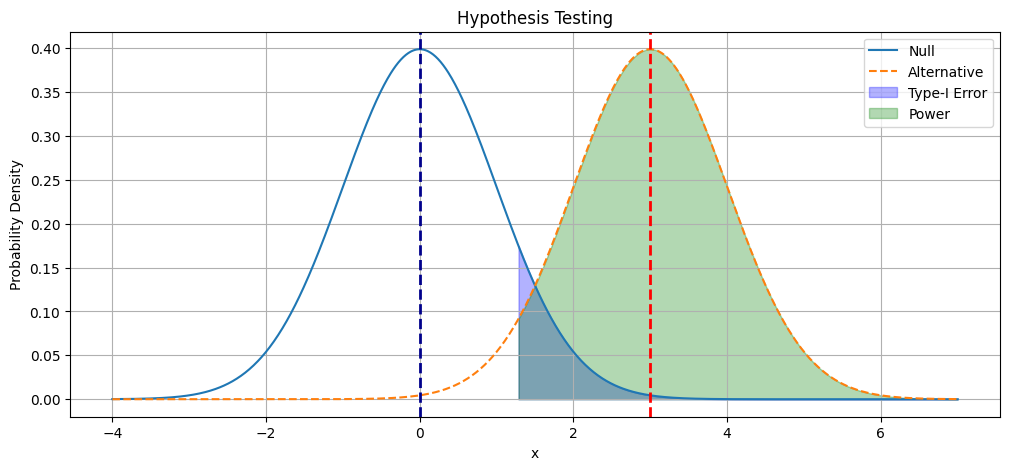

In [8]:
# Define the two distributions under the null and alternative hypotheses
x = np.linspace(-4, 7, 1000)

dist_null = norm(loc=mean_null, scale=std)
dist_alt = norm(loc=mean_alt, scale=std)

y_null = dist_null.pdf(x)
y_alt = dist_alt.pdf(x)

# Plot the two  distributions
plt.figure(figsize=(12, 5))
plt.plot(x, y_null, label="Null")
plt.plot(x, y_alt, label="Alternative", linestyle="--")
plt.axvline(x=mean_null, color="darkblue", linestyle="--", linewidth=2)
plt.axvline(x=mean_alt, color="red", linestyle="--", linewidth=2)

# Fill the area under the curves
quantile_975_dist_null = dist_null.ppf(threshold)
plt.fill_between(
    x, y_null, where=(x > quantile_975_dist_null), color="blue", alpha=0.3, label="Type-I Error"
)
plt.fill_between(
    x, y_alt, where=(x > quantile_975_dist_null), color="green", alpha=0.3, label="Power"
)

# Add labels and legend
plt.title("Hypothesis Testing")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.grid()
plt.show()

**Observations**:
- As the significance level increases (threshold value decreases),
    - (1) power (probability of detecting true effect) increases, and
    - (2) type-1 error increases (probability of false positive increases)

### B. Power Curves and MDEs

In [10]:
x = np.linspace(0, 5, 10)
threshold = dist_null.ppf(0.9)
power = norm.sf(threshold, loc=x, scale=1)

In [11]:
threshold

1.2815515655446004

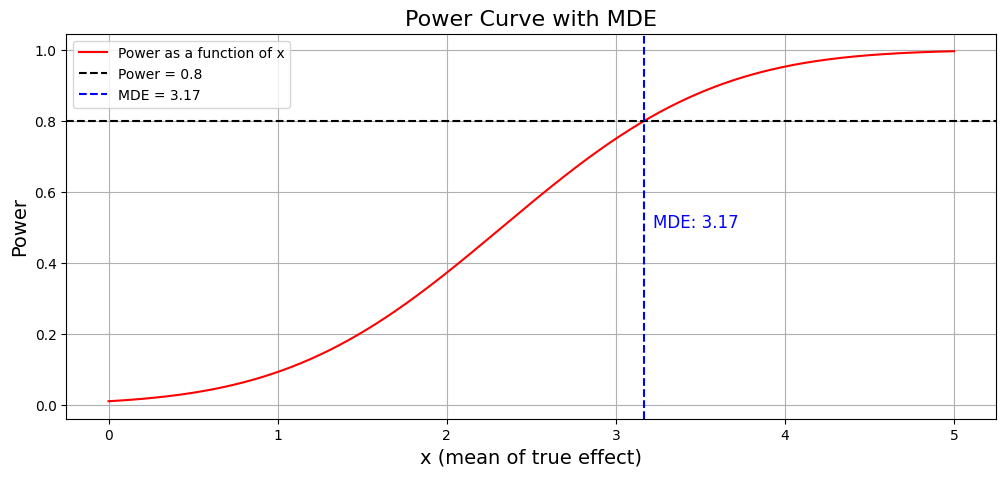

In [13]:
x = np.linspace(0, 5, 1000)
threshold = dist_null.ppf(0.99)
power = norm.sf(threshold, loc=x, scale=1)

plt.figure(figsize=(12, 5))
plt.plot(x, power, label="Power as a function of x", color="red")

# Draw a horizontal line at 0.8
plt.axhline(y=0.8, linestyle="--", color="black", label="Power = 0.8")

# Find the intersection point (where power crosses 0.8)
mde_index = np.abs(power - 0.8).argmin()
mde_x_value = x[mde_index]
mde_y_value = power[mde_index]

# Draw a vertical line at the intersection point and label it "MDE"
plt.axvline(
    x=mde_x_value, color="blue", linestyle="--", label=f"MDE = {mde_x_value:.2f}"
)
plt.text(mde_x_value + 0.05, 0.5, f"MDE: {mde_x_value:.2f}", color="blue", fontsize=12)

# Add labels and legend
plt.title("Power Curve with MDE", fontsize=16)
plt.xlabel("x (mean of true effect)", fontsize=14)
plt.ylabel("Power", fontsize=14)
plt.legend()
plt.grid()

# Show the plot
plt.show()


**MDE is a function of**:
- the significance level (5%, 10% etc) we choose (this determines the threshold)
- the desired **power** of the test


**How many samples do we need for an A/B test?**

The key factors in determining sample size for an A/B test are:

- **Minimum Detectable Effect (MDE)**: The smaller the MDE, the larger the sample size required.
- **Statistical Significance Level (α)**:
- **Statistical Power (1-β)**:

### C. Simulation Under the Alternative

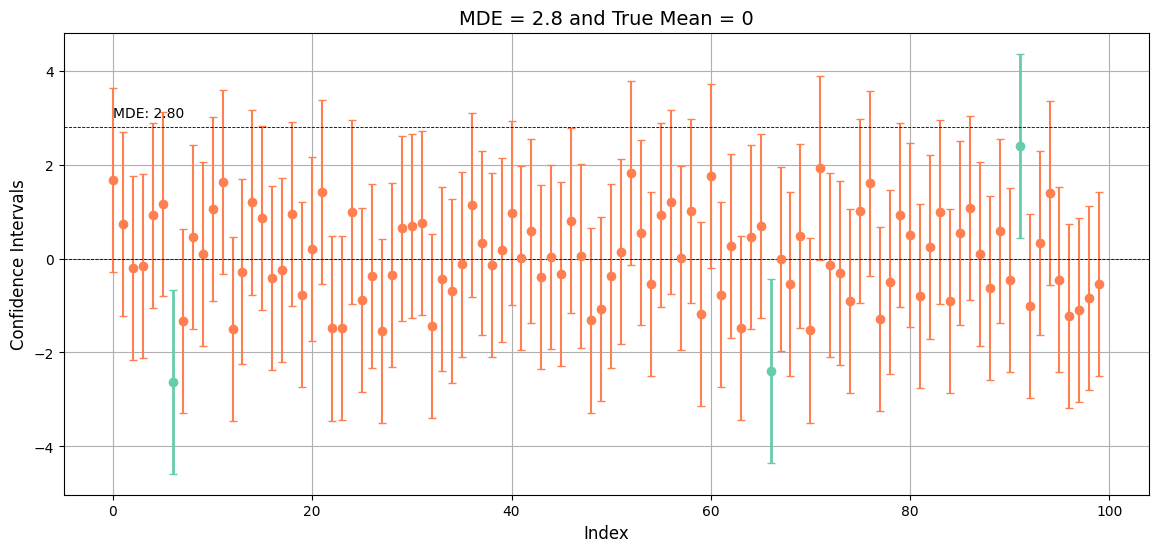

In [16]:
seed = 2024
np.random.seed(seed)

alpha = 0.05
true_mean = 0
mde = 2.8
observations = np.random.normal(true_mean, 1, 100)

z_value = stats.norm.ppf(1 - alpha / 2)
lwr = observations - z_value
upr = observations + z_value

plt.figure(figsize=(14, 6))
for i in range(100):
    if lwr[i] * upr[i] > 0:
        plt.errorbar(
            i,
            observations[i],
            yerr=[[observations[i] - lwr[i]], [upr[i] - observations[i]]],
            fmt="o",
            color="mediumaquamarine",
            ecolor="mediumaquamarine",
            elinewidth=2,
            capsize=3,
        )
    else:
        plt.errorbar(
            i,
            observations[i],
            yerr=[[observations[i] - lwr[i]], [upr[i] - observations[i]]],
            fmt="o",
            color="coral",
            ecolor="coral",
            elinewidth=1.5,
            capsize=3,
        )

plt.axhline(y=mde, color="black", linestyle="--", linewidth=0.6)
plt.text(0, mde + 0.2, f"MDE: {mde:.2f}", color="black", fontsize=10)
plt.axhline(y=0, color="black", linestyle="--", linewidth=0.6)

plt.title(f"MDE = {mde} and True Mean = {true_mean}", fontsize=14)
plt.xlabel("Index", fontsize=12)
plt.ylabel("Confidence Intervals", fontsize=12)
plt.grid()
plt.show()

## How to Design an A/B Test: A Step-by-Step Guide

1. **Define Your Goal**: What hypothesis do you want to test? Formulate a clear hypothesis to validate or disprove.
2. **Select Relevant Metrics**:
3. **Create Variations**: The thing that changes between the groups (price change, UI differences...)
4. **Define Your randomization unit**: (csku, users..)
    - How large should the sample size be? Calculate the required sample size for statistically significant results.
5. **Set the Test Duration**: Duration depends on factors like expected effect size and desired statistical significance. Implement a stop mechanism?
6. **Conduct the Test**:
7. **Analyze Results**: Verify that differences between variations are statistically significant.
these questions:

## Stratified Sampling for A/B Tests

Stratified sampling is a technique used to ensure that your A/B test sample is representative of your target population. It involves dividing the population into smaller, homogenous subgroups (strata) based on specific characteristics, and then randomly sampling from each stratum.

**Why Use Stratified Sampling in A/B Tests?**

- **Increased Precision**: By ensuring that each stratum is represented proportionally in the sample, you can reduce the variance within each group, leading to more precise estimates.
- **Reduced Bias**: Stratified sampling helps to minimize bias by ensuring that all relevant subgroups are included in the sample.
- **Improved Power**: With a more precise sample, you can detect smaller differences between the control and treatment groups with greater statistical power.

## How to determine the duration of an A/B test

1. **Sample size and statistical significance**: The primary factor in determining test duration is reaching a statistically significant result. You need a large enough sample size in each variation to confidently conclude that the observed differences are not due to chance.
2. **Business cycle and seasonality**: Consider your business cycle and seasonality when determining test duration. For example, if you're an e-commerce site like Amazon, you may need to run tests for at least a full week to capture behavior across weekdays and weekends.
3. **User behavior and purchasing cycle**: Think about your typical user behavior and purchasing cycle. If you're testing a change related to a high-consideration purchase with a long decision cycle, you may need to run the test for several weeks to fully capture the impact on conversions.
4. **Minimum detectable effect**: The smaller the minimum improvement you want to be able to detect, the larger the sample size needed and thus the longer the test duration. If you only care about detecting large effects, you can reach significance faster.